# Deep Neural Networks Lab – Week 4 (PyTorch)

**Goals:**
1) Implement deeper MLPs  
2) Analyze overfitting vs underfitting  
3) Use BatchNorm  
4) Apply Early Stopping  
5) Compare parameter counts  
6) Visualize confusion matrix and misclassified samples


## Section 1 — Setup
In this cell we:
- Import libraries
- Choose device (CPU/GPU)
- Define transforms and load MNIST
- Create train/test dataloaders


In [ ]:
import torch #Imports the main PyTorch library.
import torch.nn as nn #Imports PyTorch’s Neural Network module.
'''nn contains:
Layers (Linear, Conv2d, etc.)
Loss functions
Model building utilities
You use this to define neural network architectures.'''

import torch.nn.functional as F #for activation function
import torch.optim as optim #for optimizers Optimizers update model weights using gradients.
from torch.utils.data import DataLoader #Splits data into batches, Shuffles data, Makes iteration efficient
from torchvision import datasets, transforms #ready-made datasets like MNIST, CIFAR10, preprocessing transformation tools
import matplotlib.pyplot as plt
import numpy as np

# Reproducibility (optional)
torch.manual_seed(42)#random number genarate jonno and 42 karon jekono positive number use kora jay
np.random.seed(42)#random number genarate jonno and 42 karon jekono positive number use kora jay

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #checks if GPU is available

# MNIST transforms
transform = transforms.Compose([
    transforms.ToTensor(), #converts MNIST images to: PyTorch tensor, Scales values to 0–1 from 0-255
    transforms.Normalize((0.5,), (0.5,)) #normalize with mean 0.5, std 0.5, stabilization
])

# Download & load MNIST
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True) #MNIST training set size: 60,000 images, saved to /data and apply trans
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) #Takes dataset, Splits into batches of 64, Shuffles data every epoch
test_loader  = DataLoader(test_dataset,  batch_size=1000, shuffle=False) #No shuffling (order doesn’t matter during testing)

len(train_dataset), len(test_dataset)


# Reproducibility (optional)

(60000, 10000)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 503kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.73MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.22MB/s]


(60000, 10000)

It’s a datasets.MNIST object containing:

60,000 training images

Each image = 28×28 grayscale

Each label = digit from 0–9

sample_image → Tensor of shape [1, 28, 28]

sample_label → Integer (like 5)

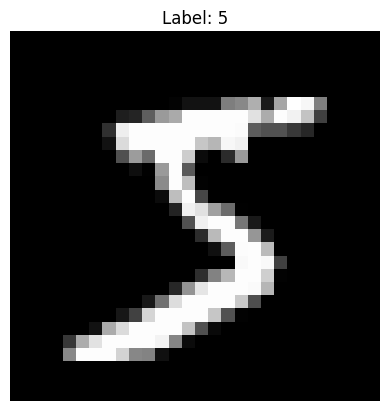

In [ ]:
# Show a sample image
sample_image, sample_label = train_dataset[0] #first data point
plt.imshow(sample_image.squeeze(), cmap='gray') #(1,28,28)--> (28,28)
plt.title(f'Label: {sample_label}')
plt.axis('off')
plt.show()

## Helper Functions
In this cell we define:
- `train_model`: trains and validates a model; supports early stopping
- `plot_losses`: plots training vs validation loss curves
- `count_parameters`: counts trainable parameters
- `compute_confusion_matrix` & `plot_confusion_matrix`: pure Matplotlib confusion matrix
- `show_misclassified`: displays misclassified test images


In [ ]:
#''' Training Loop
'''Parameters:

model → your neural network

optimizer → SGD / Adam etc.

train_loader → training batches

val_loader → validation batches

epochs → how many full passes over dataset

early_stop → whether to stop early if validation loss stops improving

patience → how many bad epochs allowed before stopping'''

def train_model(model, optimizer, train_loader, val_loader, epochs=10, early_stop=False, patience=3):
    train_losses, val_losses = [], []
    best_val = float('inf') #start with infinity loss (we want to minimize loss)
    triggers = 0 #counts how many times validation worsens
    for epoch in range(epochs):
        model.train()
        running = 0.0 #initiate sum of all batch losses
        for X, y in train_loader: #Each batch: X → shape [64, 1, 28, 28], y → shape [64]
            X, y = X.to(device), y.to(device) #Moves tensors to CPU or GPU.
            X = X.view(X.size(0), -1) # flatten to [64,784]
            optimizer.zero_grad() #So we reset before each backward pass.
            out = model(X) #predicted output, [64,10]
            loss = F.cross_entropy(out, y) #Combines softmax + log + negative likelihood
            loss.backward() #compute gradients
            optimizer.step() #applies gradient update
            running += loss.item() #.item means tensor to number
        train_losses.append(running / len(train_loader)) #avg loss for this epoch, len(train_loader) = batch size

        model.eval() #Disables:Dropout and Training behavior of BatchNorm
        vloss, correct = 0.0, 0
        with torch.no_grad(): #no need of gradients during testing
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                X = X.view(X.size(0), -1)
                out = model(X)
                loss = F.cross_entropy(out, y)
                vloss += loss.item()
                pred = out.argmax(dim=1) #Chooses class with highest probability
                correct += (pred == y).sum().item() #how many correct
        vloss /= len(val_loader)
        acc = 100.0 * correct / len(val_loader.dataset)
        val_losses.append(vloss)
        print(f"Epoch {epoch+1}: Train {train_losses[-1]:.4f} | Val {vloss:.4f} | Acc {acc:.2f}%")
        '''If validation loss lowers:

        reset triggers

        If not:

        increment triggers

        If triggers ≥ patience:

        stop training

        This prevents overfitting.'''

        if early_stop:
            if vloss < best_val:
                best_val = vloss
                triggers = 0
            else:
                triggers += 1
                if triggers >= patience:
                    print('Early stopping triggered!')
                    break
    return train_losses, val_losses

def plot_losses(train_losses, val_losses, title):
    plt.figure(figsize=(6,4))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad) #count all trainable parameters (weights and biases)

def compute_confusion_matrix(model, loader, num_classes=10):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    model.eval() #Disables:Dropout and Training behavior of BatchNorm
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            out = model(X.view(X.size(0), -1))
            preds = out.argmax(dim=1).cpu().numpy()
            y_np = y.numpy()
            for t, p in zip(y_np, preds):
                cm[t, p] += 1
    return cm

def plot_confusion_matrix(cm, title='Confusion Matrix'):
    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(range(cm.shape[1]))
    plt.yticks(range(cm.shape[0]))
    # annotate counts
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def show_misclassified(model, loader, n=6):# n is number of wrong preds to display
    model.eval()
    wrong = []
    with torch.no_grad():
        for X, y in loader:#X is image, y is true label
            out = model(X.to(device).view(X.size(0), -1)) #flatten image
            preds = out.argmax(dim=1).cpu() #picks class with highest score
            for i in range(len(y)):
                if preds[i].item() != y[i].item():
                    wrong.append((X[i].squeeze(0), preds[i].item(), y[i].item()))#remove channel dim
                if len(wrong) >= n:
                    break
            if len(wrong) >= n:
                break
    plt.figure(figsize=(12,3))
    for i, (img, pred, true) in enumerate(wrong[:n]):
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f'P:{pred} | T:{true}')
        plt.axis('off')
    plt.show()

## Section 2 — Implement Deeper MLPs (Architecture)
We define a flexible MLP that takes a list of layer sizes (including input and output).

Input (784)
 ↓
Linear(784→128) + ReLU
 ↓
Linear(128→64) + ReLU
 ↓
Linear(64→10)   ← Output logits

In [ ]:
class MLP(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)])
    def forward(self, x):
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        return self.layers[-1](x)

### Train: Shallow MLP,  only 1 hidden
We train a shallow network (1 hidden layer, 64 units) for 5 epochs and plot the loss curves. We also print the number of trainable parameters.

Epoch 1: Train 0.4445 | Val 0.2635 | Acc 92.17%
Epoch 2: Train 0.2568 | Val 0.2263 | Acc 93.37%
Epoch 3: Train 0.2090 | Val 0.1888 | Acc 94.46%
Epoch 4: Train 0.1794 | Val 0.1584 | Acc 95.15%
Epoch 5: Train 0.1560 | Val 0.1458 | Acc 95.47%
Trainable Parameters: 50890


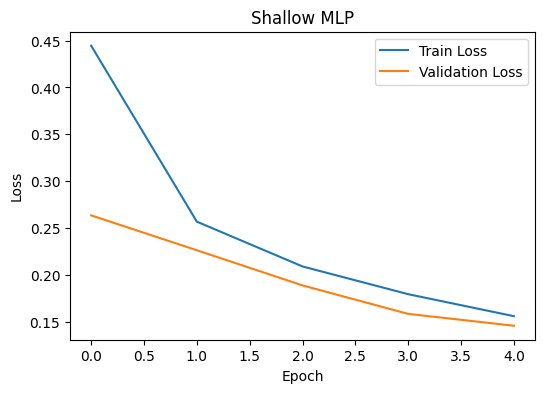

In [ ]:
model_shallow = MLP([784, 64, 10]).to(device)
opt = optim.Adam(model_shallow.parameters(), lr=1e-3)
tr, va = train_model(model_shallow, opt, train_loader, test_loader, epochs=5)
print('Trainable Parameters:', count_parameters(model_shallow))
plot_losses(tr, va, 'Shallow MLP')

Epoch 1: Train 0.3934 | Val 0.1910 | Acc 94.35%
Epoch 2: Train 0.1639 | Val 0.1364 | Acc 95.79%
Epoch 3: Train 0.1222 | Val 0.1146 | Acc 96.41%
Epoch 4: Train 0.0991 | Val 0.1261 | Acc 96.09%
Epoch 5: Train 0.0847 | Val 0.0840 | Acc 97.47%
Trainable Parameters: 242762


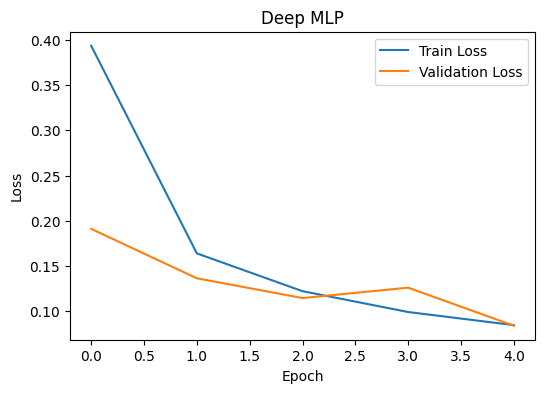

In [ ]:
model_deep = MLP([784, 256, 128, 64, 10]).to(device)
opt = optim.Adam(model_deep.parameters(), lr=1e-3)
tr, va = train_model(model_deep, opt, train_loader, test_loader, epochs=5)
print('Trainable Parameters:', count_parameters(model_deep))
plot_losses(tr, va, 'Deep MLP')

### Train: Deep MLP
We now train a deeper network (3 hidden layers: 256, 128, 64) for 5 epochs and compare the curves to the shallow model.

## Section 3 — Overfitting vs Underfitting
We contrast two extremes:
- **Underfitting:** very small model (16 hidden units)
- **Overfitting:** very large model (multiple wide layers)

### Underfitting: Tiny Model
Train a very small network for 5 epochs and observe high bias (both train and val losses high).

Epoch 1: Train 1.0219 | Val 0.6961 | Acc 79.75%
Epoch 2: Train 0.6612 | Val 0.6016 | Acc 82.62%
Epoch 3: Train 0.5977 | Val 0.5834 | Acc 83.05%
Epoch 4: Train 0.5657 | Val 0.5472 | Acc 84.80%
Epoch 5: Train 0.5448 | Val 0.5291 | Acc 84.34%
Trainable Parameters: 6370


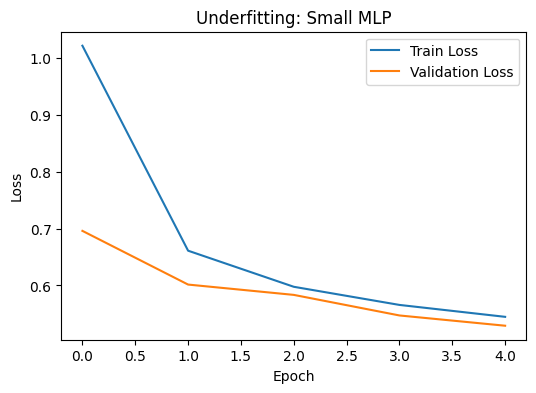

In [ ]:
model_small = MLP([784, 8, 10]).to(device)
opt = optim.Adam(model_small.parameters(), lr=1e-3)
tr, va = train_model(model_small, opt, train_loader, test_loader, epochs=5)
print('Trainable Parameters:', count_parameters(model_small))
plot_losses(tr, va, 'Underfitting: Small MLP')

### Overfitting: Very Large Model
Train a much larger model (more layers and units) for 10 epochs. Expect low train loss but higher validation loss as overfitting kicks in.

Epoch 1: Train 0.4458 | Val 0.2407 | Acc 92.73%
Epoch 2: Train 0.1770 | Val 0.1662 | Acc 94.96%
Epoch 3: Train 0.1301 | Val 0.1164 | Acc 96.75%
Epoch 4: Train 0.1121 | Val 0.1093 | Acc 96.96%
Epoch 5: Train 0.0939 | Val 0.1312 | Acc 96.29%
Epoch 6: Train 0.0875 | Val 0.1023 | Acc 97.22%
Epoch 7: Train 0.0750 | Val 0.1364 | Acc 96.40%
Epoch 8: Train 0.0680 | Val 0.0824 | Acc 97.72%
Epoch 9: Train 0.0606 | Val 0.0962 | Acc 97.28%
Epoch 10: Train 0.0557 | Val 0.0904 | Acc 97.89%
Trainable Parameters: 1764426


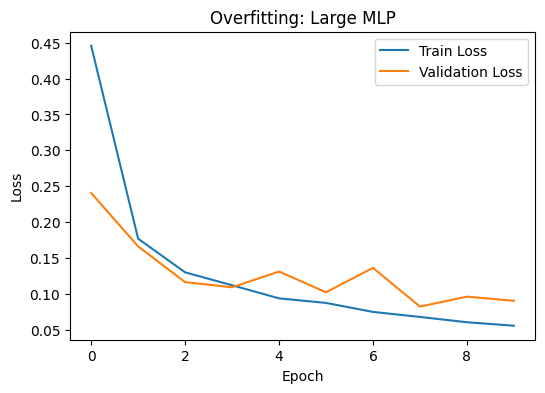

In [ ]:
model_large = MLP([784, 1024, 512, 512, 256, 128, 64, 10]).to(device)
opt = optim.Adam(model_large.parameters(), lr=1e-3)
tr, va = train_model(model_large, opt, train_loader, test_loader, epochs=10)
print('Trainable Parameters:', count_parameters(model_large))
plot_losses(tr, va, 'Overfitting: Large MLP')

## Section 4 — Batch Normalization
We add BatchNorm to a deep MLP to stabilize gradients and speed up convergence.

In [ ]:
class MLPBatchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.fc4 = nn.Linear(64, 10)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        return self.fc4(x)

### Train: Deep MLP with BatchNorm
Train for 5 epochs and compare to the non-BN deep MLP.

Epoch 1: Train 0.2344 | Val 0.0942 | Acc 97.01%
Epoch 2: Train 0.0913 | Val 0.0751 | Acc 97.63%
Epoch 3: Train 0.0652 | Val 0.0716 | Acc 97.87%
Epoch 4: Train 0.0517 | Val 0.0591 | Acc 98.11%
Epoch 5: Train 0.0422 | Val 0.0636 | Acc 98.02%
Trainable Parameters: 243658


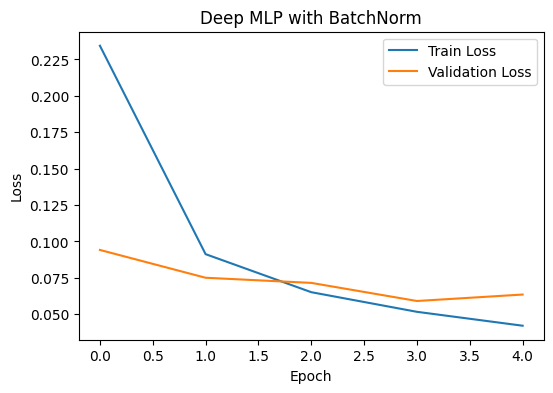

In [ ]:
model_bn = MLPBatchNorm().to(device)
opt = optim.Adam(model_bn.parameters(), lr=1e-3)
tr, va = train_model(model_bn, opt, train_loader, test_loader, epochs=5)
print('Trainable Parameters:', count_parameters(model_bn))
plot_losses(tr, va, 'Deep MLP with BatchNorm')

## Section 5 — Early Stopping
We train a deep MLP and enable early stopping (patience=3) to prevent overfitting.

### Train: Deep MLP with Early Stopping
Use the same architecture as the earlier deep MLP and run up to 20 epochs, but stop early if validation loss doesn't improve for 3 epochs.

Epoch 1: Train 0.3822 | Val 0.1926 | Acc 93.97%
Epoch 2: Train 0.1647 | Val 0.1276 | Acc 95.99%
Epoch 3: Train 0.1224 | Val 0.1246 | Acc 96.18%
Epoch 4: Train 0.0969 | Val 0.1136 | Acc 96.31%
Epoch 5: Train 0.0850 | Val 0.1289 | Acc 96.00%
Epoch 6: Train 0.0722 | Val 0.0912 | Acc 97.20%
Epoch 7: Train 0.0636 | Val 0.1203 | Acc 96.38%
Epoch 8: Train 0.0544 | Val 0.0936 | Acc 97.46%
Epoch 9: Train 0.0527 | Val 0.0719 | Acc 97.77%
Epoch 10: Train 0.0468 | Val 0.0998 | Acc 97.30%
Epoch 11: Train 0.0416 | Val 0.0857 | Acc 97.54%
Epoch 12: Train 0.0375 | Val 0.0761 | Acc 97.93%
Early stopping triggered!
Trainable Parameters: 242762


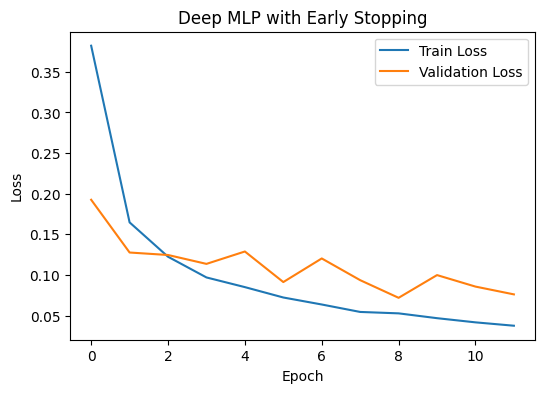

In [ ]:
model_es = MLP([784, 256, 128, 64, 10]).to(device)
opt = optim.Adam(model_es.parameters(), lr=1e-3)
tr, va = train_model(model_es, opt, train_loader, test_loader, epochs=20, early_stop=True, patience=3)
print('Trainable Parameters:', count_parameters(model_es))
plot_losses(tr, va, 'Deep MLP with Early Stopping')

## Section 6 — Confusion Matrix & Misclassified Samples
We evaluate the final (early-stopped) model on the test set and visualize:
- Confusion matrix (pure Matplotlib)
- A few misclassified examples with predicted vs true labels

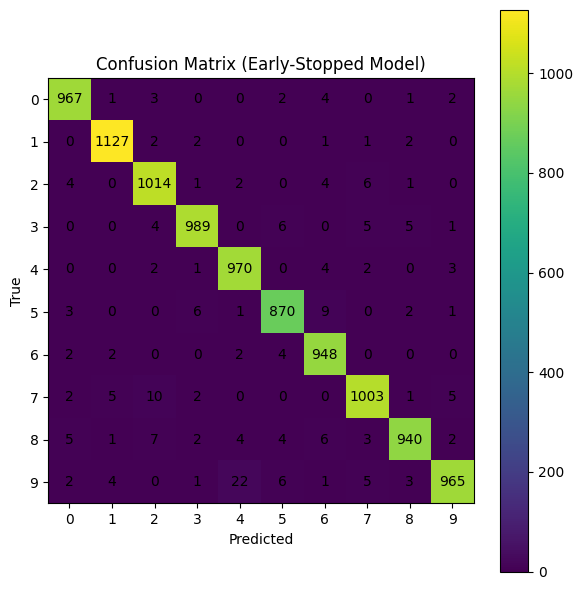

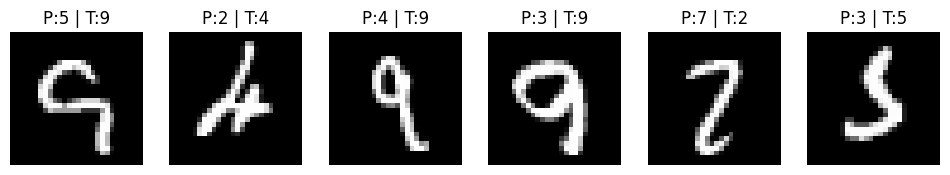

In [ ]:
cm = compute_confusion_matrix(model_es, test_loader, num_classes=10)
plot_confusion_matrix(cm, title='Confusion Matrix (Early-Stopped Model)')
show_misclassified(model_es, test_loader, n=6)